# Otimização de potência em uma rede de servidores
____
- Nome: Pedro Henrique Simões de Mendonça
- Matrícula: 2023100593
____

**Informações importantes:**
- Organização é critério de avaliação. Deixe o seu Notebook (Código + Markdown) o mais organizado possível para que seja possível avaliá-lo.
- Você pode criar quantas células forem necessárias, respeitando as seções disponibilizadas neste template.
- Não é necessário limpar o notebook na entrega (ou seja, deixe os plots e resultados)

## Modelagem computacional do problema
- Na(s) células a seguir, inserir a modelagem do problema, bem como constantes, se entender necessário.
- Utilize Markdown para explicar algum conceito.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

CARGAS = [18, 10, 18, 70, 42, 25, 28, 42]
DISTANCIAS = [20, 50, 21, 15, 10, 39, 25, 10]

N_GENES = 8
POP = 80
GERACOES = 30
MUT = 0.15

In [2]:
def custo_total(ind):
    # custo agora depende dos valores do indivíduo (por elemento)
    return sum(1.8 * CARGAS[i] * ind[i] for i in range(len(ind)))

In [3]:
def qmax(ind):
    for i in range(N_GENES):
        P = 0.12 * (ind[i] ** 2)
        T = (CARGAS[i] ** 1.4) * DISTANCIAS[i] / (P ** 1.5)
        if T <= 18:
            return T
    return T

In [4]:
def fitness(ind):
    return custo_total(ind) if qmax(ind) <= 18 else 18

## Implementação do algoritmo 1
- Nas célula(s) a seguir implemente o algoritmo 1 escolhido
- No final da execução apresente a média e o desvio padrão para 30 execuções do algoritmo
- Apresente também o plot da convergência do algoritmo

In [5]:
def selecao(pop):
    # random.sample doesn't accept numpy arrays directly; sample indices instead
    i, j = random.sample(range(len(pop)), 2)
    k, l = random.sample(range(len(pop)), 2)
    a, b = pop[i], pop[j]
    c, d = pop[k], pop[l]

    pai = a if fitness(a) < fitness(b) else b
    mae = c if fitness(c) < fitness(d) else d

    return pai, mae

In [6]:
def crossover(pai, mae):
    ponto = random.randint(1, len(pai) - 1)
    return np.concatenate([pai[:ponto], mae[ponto:]])

In [7]:
def mutacao(ind):
    if random.random() < MUT:
        i = random.randint(0, len(ind) - 1)
        ind[i] = random.randint(0, 7)
    return ind

In [8]:
def init_populacao():
    return np.random.uniform(10, 50, size=(POP, 8))

In [9]:
def ga():
    pop = init_populacao()
    melhor = min(pop, key=fitness)

    historico = []
    for _ in range(GERACOES):
        nova = []
        while len(nova) < POP:
            pai, mae = selecao(pop)
            filho = crossover(pai, mae)
            filho = mutacao(filho)
            nova.append(filho)
        pop = nova
        atual = min(pop, key=fitness)
        if(fitness(atual) < fitness(melhor)):
            melhor = atual
        historico.append(min([fitness(ind) for ind in pop]))
    plt.plot(historico)
    plt.title('Evolução')
    plt.xlabel('Geração')
    plt.ylabel('Melhor Fitness')
    plt.savefig('evolucao_ga.png')
    melhor_ind = min(pop, key=fitness)
    return melhor_ind, historico

## Implementação algoritmo 2
- Nas célula(s) a seguir implemente o algoritmo 1 escolhido
- No final da execução apresente a média e o desvio padrão para 30 execuções do algoritmo
- Apresente também o plot da convergência do algoritmo

In [10]:
# def de():
#     return 0

Melhor fitness: 18


/tmp/ipykernel_1623093/2611509078.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  T = (CARGAS[i] ** 1.4) * DISTANCIAS[i] / (P ** 1.5)


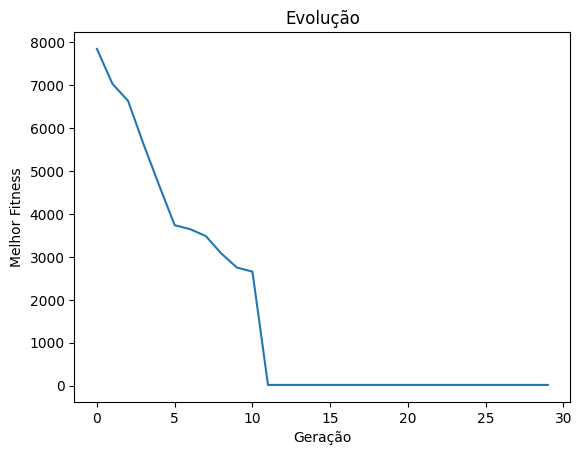

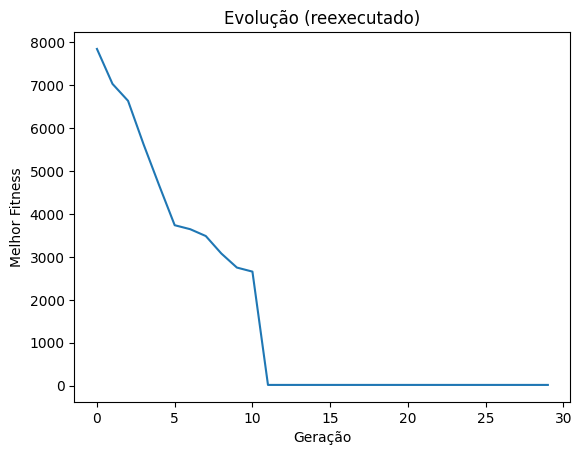

In [11]:
melhor_ind, historico = ga()
print('Melhor fitness:', fitness(melhor_ind))
plt.figure()
plt.plot(historico)
plt.title('Evolução (reexecutado)')
plt.xlabel('Geração')
plt.ylabel('Melhor Fitness')
plt.savefig('evolucao_ga_executed.png')
plt.show()

## Comparação dos algoritmos
- Por fim, coloque os resultados finais (de média e desvio padrão) dos algoritmos
- Faça uma breve análise dos resultados obtidos
- Quem foi melhor (se houver)? Qual você escolheria? Justifique suas escolhas baseados em evidências